In [ ]:
pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13

In [ ]:
pip install dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/YoutubeCommentsDataSet.csv")

In [ ]:
df.drop_duplicates(inplace=True)
df = df[~(df['Comment'].str.strip() == '')]

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
# Ensure necessary NLTK data is downloaded
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:


# Initialize once (outside the function)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

def preprocess_comment(comment):

    # Handle missing values
    if not isinstance(comment, str):
        return ""

    # Convert to lowercase
    comment = comment.lower()

    # Remove leading/trailing spaces
    comment = comment.strip()

    # Replace newlines with spaces
    comment = re.sub(r'\n+', ' ', comment)

    # Remove URLs
    comment = re.sub(r'http\S+|www\S+', '', comment)

    # Remove HTML tags
    comment = re.sub(r'<.*?>', '', comment)

    # Remove mentions and hashtags
    comment = re.sub(r'@\w+|#\w+', '', comment)

    # Keep only letters, numbers, spaces, and basic punctuation
    comment = re.sub(r'[^a-zA-Z0-9\s!?.,]', '', comment)

    # Remove extra spaces
    comment = re.sub(r'\s+', ' ', comment).strip()

    # Remove stopwords
    words = [word for word in comment.split() if word not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [ ]:
df = df[df['Comment'].notna()].copy()

df['Comment'] = df['Comment'].apply(preprocess_comment)

In [ ]:
df.head()

,Comment,Sentiment
0,let not forget apple pay 2014 required brand n...,neutral
1,nz 50 retailer dont even contactless credit ca...,negative
2,forever acknowledge channel help lesson idea e...,positive
3,whenever go place doesnt take apple pay doesnt...,negative
4,apple pay convenient secure easy use used kore...,positive


In [ ]:
df.to_csv('/content/preprocessed_data.csv')

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
vectorizer = CountVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['Comment']).toarray()
y = df['Sentiment']  # Assuming 'sentiment' is the target variable (0 or 1 for binary classification)

In [ ]:
X.shape

(17874, 10000)

In [ ]:
y

,Sentiment
0,neutral
1,negative
2,positive
3,negative
4,positive
...,...
18403,positive
18404,positive
18405,neutral
18406,positive


In [ ]:
print(df["Sentiment"].dtype)
print(df["Sentiment"].unique())

int64
[ 0 -1  1]


In [ ]:
df

,Comment,Sentiment
0,let not forget apple pay 2014 required brand n...,0
1,nz 50 retailer dont even contactless credit ca...,-1
2,forever acknowledge channel help lesson idea e...,1
3,whenever go place doesnt take apple pay doesnt...,-1
4,apple pay convenient secure easy use used kore...,1
...,...,...
18403,really like point engineering toolbox think th...,1
18404,ive started exploring field really good remind...,1
18405,excelente video con una pregunta filosfica pro...,0
18406,hey daniel discovered channel couple day ago i...,1


In [ ]:
print(y.dtype)
print(y.unique)


int64
<bound method Series.unique of 0        0
1       -1
2        1
3       -1
4        1
        ..
18403    1
18404    1
18405    0
18406    1
18407    1
Name: Sentiment, Length: 17874, dtype: int64>


In [ ]:
print(y.dtype)
print(y.unique)


int64
<bound method Series.unique of 0        0
1       -1
2        1
3       -1
4        1
        ..
18403    1
18404    1
18405    0
18406    1
18407    1
Name: Sentiment, Length: 17874, dtype: int64>


In [ ]:
import dagshub
dagshub.init(repo_owner='panchariyarohit486', repo_name='youtube-sentiment-analysis', mlflow=True)


❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=55a4fd19-a14f-4e71-a310-b12bc2aa7cc3&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bb30a6c5e5b99076adfa5a28f505fd9ecb7e3efa0c81dd2b29b2ea8c7f804d0c




Accessing as panchariyarohit486

Initialized MLflow to track repo "panchariyarohit486/youtube-sentiment-analysis"

Repository panchariyarohit486/youtube-sentiment-analysis initialized!

In [ ]:
# Step 2: Set up the MLflow tracking serve
mlflow.set_tracking_uri("https://dagshub.com/panchariyarohit486/youtube-sentiment-analysis.mlflow/")

In [ ]:
import mlflow

print(mlflow.get_tracking_uri())

https://dagshub.com/panchariyarohit486/youtube-sentiment-analysis.mlflow/


In [ ]:
# Set or create an experiment
mlflow.set_experiment("RF Baseline")

2026/07/10 13:43:07 INFO mlflow.tracking.fluent: Experiment with name 'RF Baseline' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/9625cc4815854e86abdf1117db2bda32', creation_time=1783690987620, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1783690987620, lifecycle_stage='active', name='RF Baseline', tags={}, trace_location=None, workspace='default'>

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
2026/07/10 13:44:23 WARNING mlflow.models.model: 

🏃 View run RandomForest_Baseline_TrainTestSplit at: https://dagshub.com/panchariyarohit486/youtube-sentiment-analysis.mlflow/#/experiments/0/runs/776ced78d33746daa6427838b1cba7e7
🧪 View experiment at: https://dagshub.com/panchariyarohit486/youtube-sentiment-analysis.mlflow/#/experiments/0
Accuracy: 0.6243356643356643


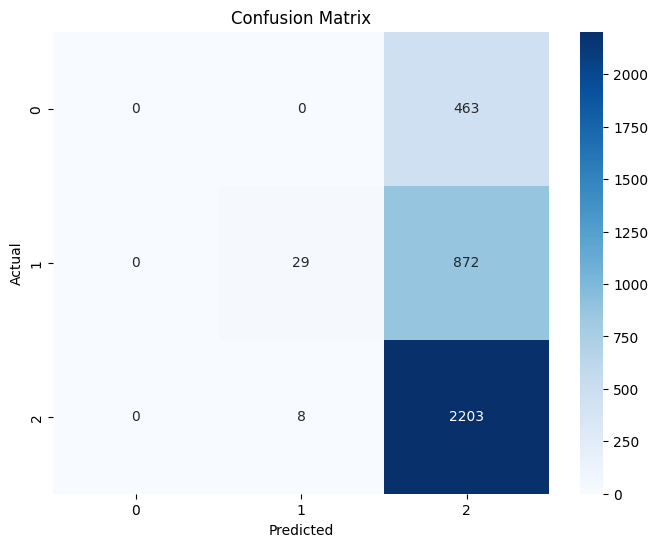

In [ ]:
X_train, X_test ,y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state=42 , stratify = y)
with mlflow.start_run() as run:
   # log the discription for the run
    mlflow.set_tag("mlflow.runName", "RandomForest_Baseline_TrainTestSplit")
    mlflow.set_tag("experiment_type", "baseline")
    mlflow.set_tag("model_type", "RandomForestClassifier")

    #add a discription
    mlflow.set_tag("description", "Baseline RandomForest model for sentiment analysis using Bag of Words (BoW) with a simple train-test split")

    #log parameters for the vectorizer
    mlflow.log_param("vectorizer_type", "CountVectorizer")
    mlflow.log_param("vectorizer_max_features", vectorizer.max_features)


    # Log Random Forest parameters
    n_estimators = 200
    max_depth = 15

    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    #train the base_model
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Log metrics for each class and accuracy
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    classification_rep = classification_report(y_test, y_pred, output_dict=True)

    for label, metrics in classification_rep.items():
        if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
            for metric, value in metrics.items():
                mlflow.log_metric(f"{label}_{metric}", value)


    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    # Save and log the confusion matrix plot
    plt.savefig("confusion_matrix.png")
    mlflow.log_artifact("/content/confusion_matrix.png")

    # Log the Random Forest model
    mlflow.sklearn.log_model(model, "random_forest_model")

    # Optionally log the dataset itself (if it's small enough)
    df.to_csv("dataset.csv", index=False)
    mlflow.log_artifact("/content/dataset.csv")

# Display final accuracy
print(f"Accuracy: {accuracy}")



In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00       463
           0       0.78      0.03      0.06       901
           1       0.62      1.00      0.77      2211

    accuracy                           0.62      3575
   macro avg       0.47      0.34      0.28      3575
weighted avg       0.58      0.62      0.49      3575



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
